LIBRARIES

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


DATA LOADING 

In [5]:
client = pd.read_csv('client_data (1).csv')
price = pd.read_csv ('price_data (1).csv')

In [6]:
client.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [7]:
price.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


DATA CLEANING

In [8]:

client = client.dropna()
price = price.dropna()


DATA TYPES

In [9]:
client.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [10]:
price.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 19.5 MB


DATA VISUALISATION

CHURN ANALYSIS

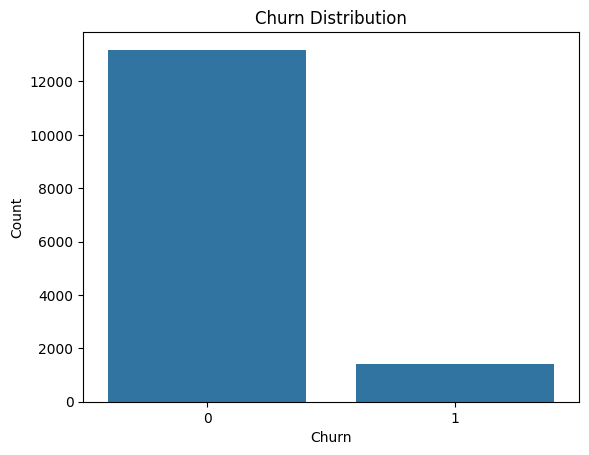

In [16]:

sns.countplot(x='churn', data= client)
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


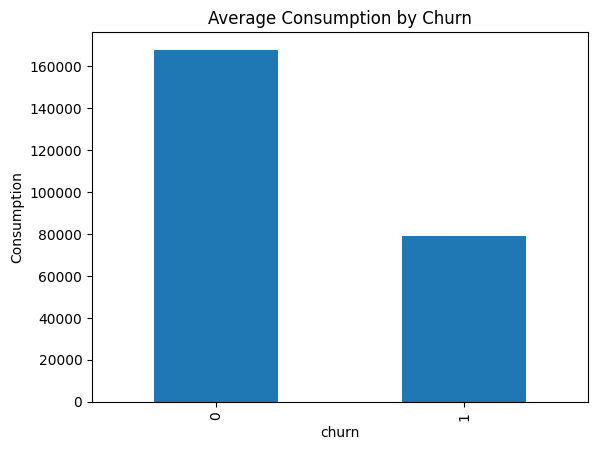

In [19]:
client.groupby('churn')['cons_12m'].mean().plot(kind='bar')
plt.title('Average Consumption by Churn')
plt.ylabel('Consumption')
plt.show()

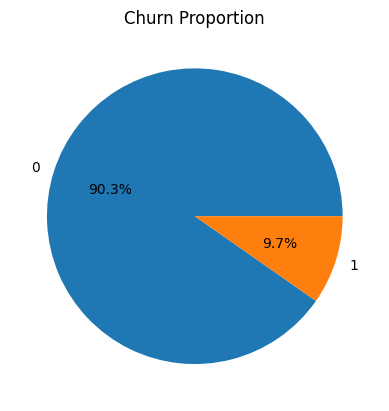

In [26]:
client['churn'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Churn Proportion')
plt.show()

CONSUMPTION ANALYSIS

In [38]:

client['avg_monthly_cons'] = client['cons_12m'] / 12

client['cons_trend_ratio'] = client['cons_last_month'] / client['avg_monthly_cons']

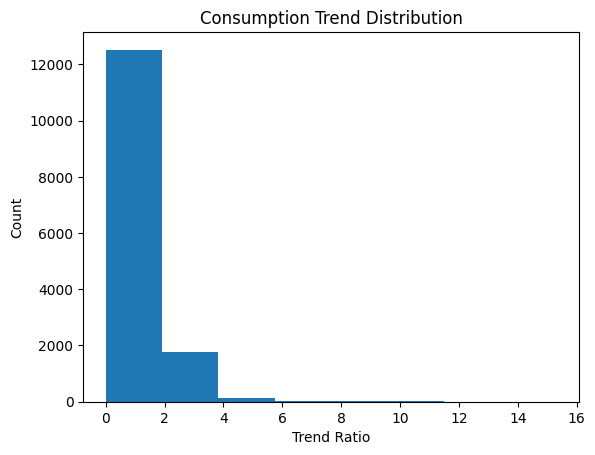

In [40]:
plt.hist(client['cons_trend_ratio'], bins=8)
plt.title('Consumption Trend Distribution')
plt.xlabel('Trend Ratio')
plt.ylabel('Count')
plt.show()

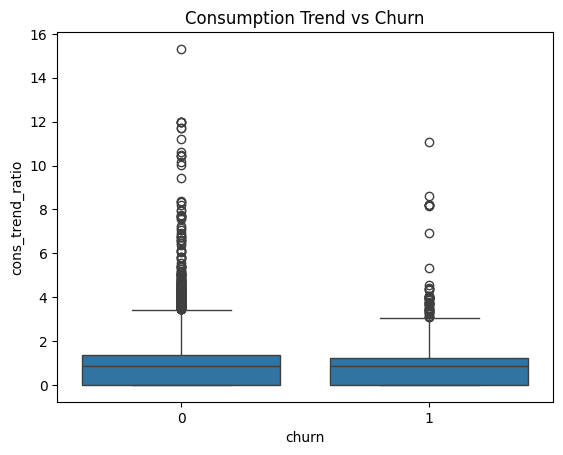

In [44]:

sns.boxplot(x='churn', y='cons_trend_ratio', data=client)
plt.title('Consumption Trend vs Churn')
plt.show()


PRICING ANALYSIS 

In [47]:
price_trend = price.groupby('price_date')['price_peak_var'].mean()

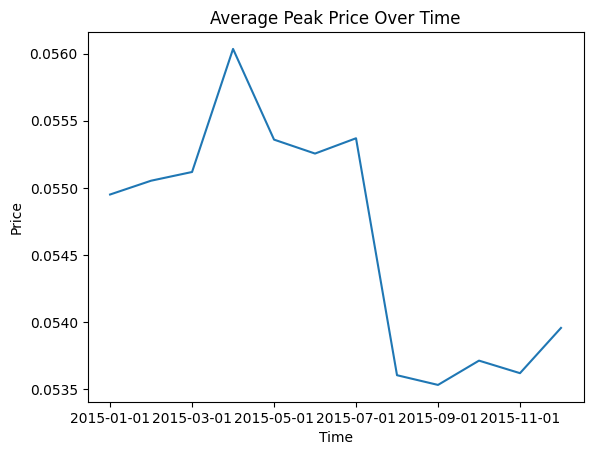

In [50]:

price_trend.plot()
plt.title('Average Peak Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()


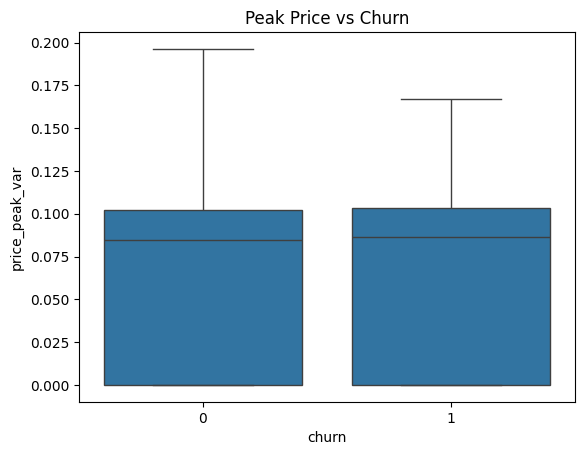

In [56]:
sns.boxplot(x='churn', y='price_peak_var', data=client_price)
plt.title('Peak Price vs Churn')
plt.show()


FORECAST VS ACTUAL ANALYSIS

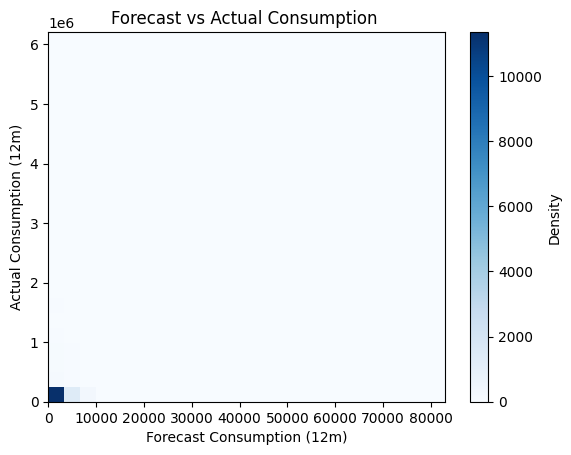

In [75]:
plt.hist2d(
    client['forecast_cons_12m'],
    client['cons_12m'],
    bins=25,
    cmap='Blues'
)

plt.colorbar(label='Density')
plt.xlabel('Forecast Consumption (12m)')
plt.ylabel('Actual Consumption (12m)')
plt.title('Forecast vs Actual Consumption ')
plt.show()




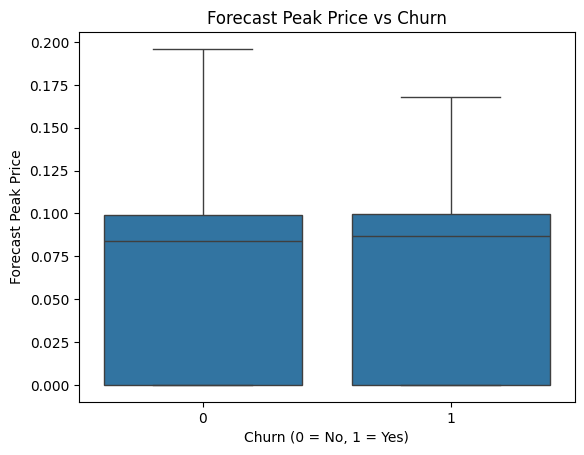

In [67]:
sns.boxplot(x='churn', y='forecast_price_energy_peak', data=client)
plt.title('Forecast Peak Price vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Forecast Peak Price')
plt.show()


TIME BASED ANALYSIS

MARGIN ANALYSIS


CORRELATION

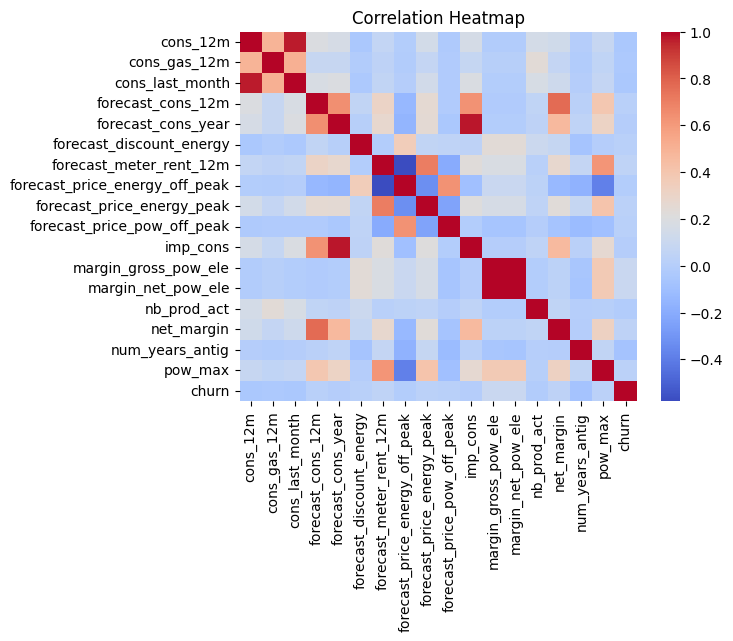

In [28]:

corr = client.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
